---
## Imports

In [1]:
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json, warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi":150,"axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,"grid.alpha":0.3})
PALETTE = ["#e74c3c","#e67e22","#f1c40f","#2ecc71","#1abc9c","#3498db","#9b59b6"]
print("Config loaded ok")

Config loaded ok


---
## Load Dataset

In [2]:
df = pd.read_csv(META_PATH)

def find_image_path(image_id):
    for folder in [IMG_DIR_1, IMG_DIR_2]:
        p = folder / (image_id + ".jpg")
        if p.exists():
            return str(p)
    return None

df["path"]  = df["image_id"].apply(find_image_path)
df["label"] = df["dx"].map(CLASS_TO_IDX)
missing = df["path"].isna().sum()
df = df.dropna(subset=["path"]).reset_index(drop=True)
print(f"Images found:   {len(df):,}")
print(f"Images missing: {missing}")
print(f"\nClass distribution:")
print(df["dx"].value_counts().to_string())

Images found:   2,823
Images missing: 7192

Class distribution:
dx
nv       1932
bkl       322
mel       245
bcc       143
akiec     107
vasc       41
df         33


---
## Class Distribution -- The Imbalance Problem

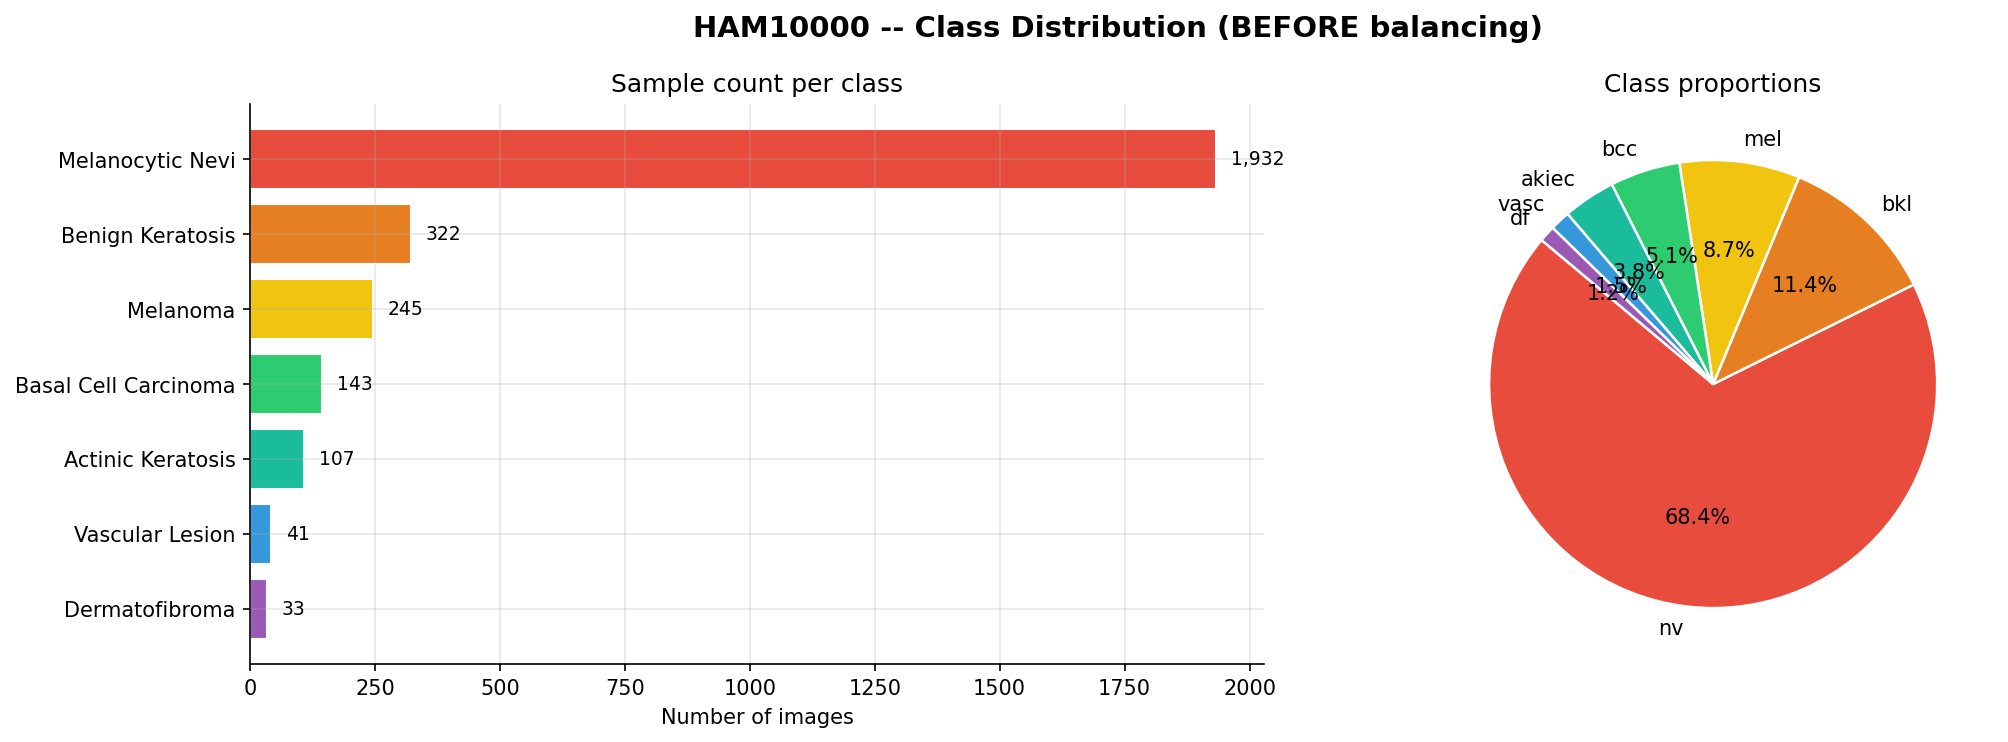


Imbalance ratio: 58.5x (nv vs df)
v2 fix: upsample all classes to 6,705 via per-class GANs

Synthetic images needed per class:
  nv    : 1,932 real + 4,773 synthetic = 6,705 total
  bkl   :   322 real + 6,383 synthetic = 6,705 total
  mel   :   245 real + 6,460 synthetic = 6,705 total
  bcc   :   143 real + 6,562 synthetic = 6,705 total
  akiec :   107 real + 6,598 synthetic = 6,705 total
  vasc  :    41 real + 6,664 synthetic = 6,705 total
  df    :    33 real + 6,672 synthetic = 6,705 total


In [3]:
counts    = df["dx"].value_counts().sort_values(ascending=False)
fullnames = [CLASS_FULLNAME[c] for c in counts.index]
imbalance = counts.max() / counts.min()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("HAM10000 -- Class Distribution (BEFORE balancing)", fontsize=14, fontweight="bold")

bars = axes[0].barh(fullnames[::-1], counts.values[::-1],
                    color=PALETTE[:len(counts)][::-1], edgecolor="white")
axes[0].set_xlabel("Number of images")
axes[0].set_title("Sample count per class")
for bar, val in zip(bars, counts.values[::-1]):
    axes[0].text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
                 f"{val:,}", va="center", fontsize=9)

axes[1].pie(counts.values, labels=counts.index, colors=PALETTE[:len(counts)],
            autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor":"white","linewidth":1.2})
axes[1].set_title("Class proportions")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_class_distribution.png", bbox_inches="tight")
plt.show()

print(f"\nImbalance ratio: {imbalance:.1f}x (nv vs df)")
print(f"v2 fix: upsample all classes to {TARGET_COUNT:,} via per-class GANs")
print(f"\nSynthetic images needed per class:")
for cls in counts.index:
    n_real = counts[cls]
    n_needed = max(0, TARGET_COUNT - n_real)
    print(f"  {cls:6s}: {n_real:5,} real + {n_needed:5,} synthetic = {TARGET_COUNT:,} total")

---
## Sample Images per Class

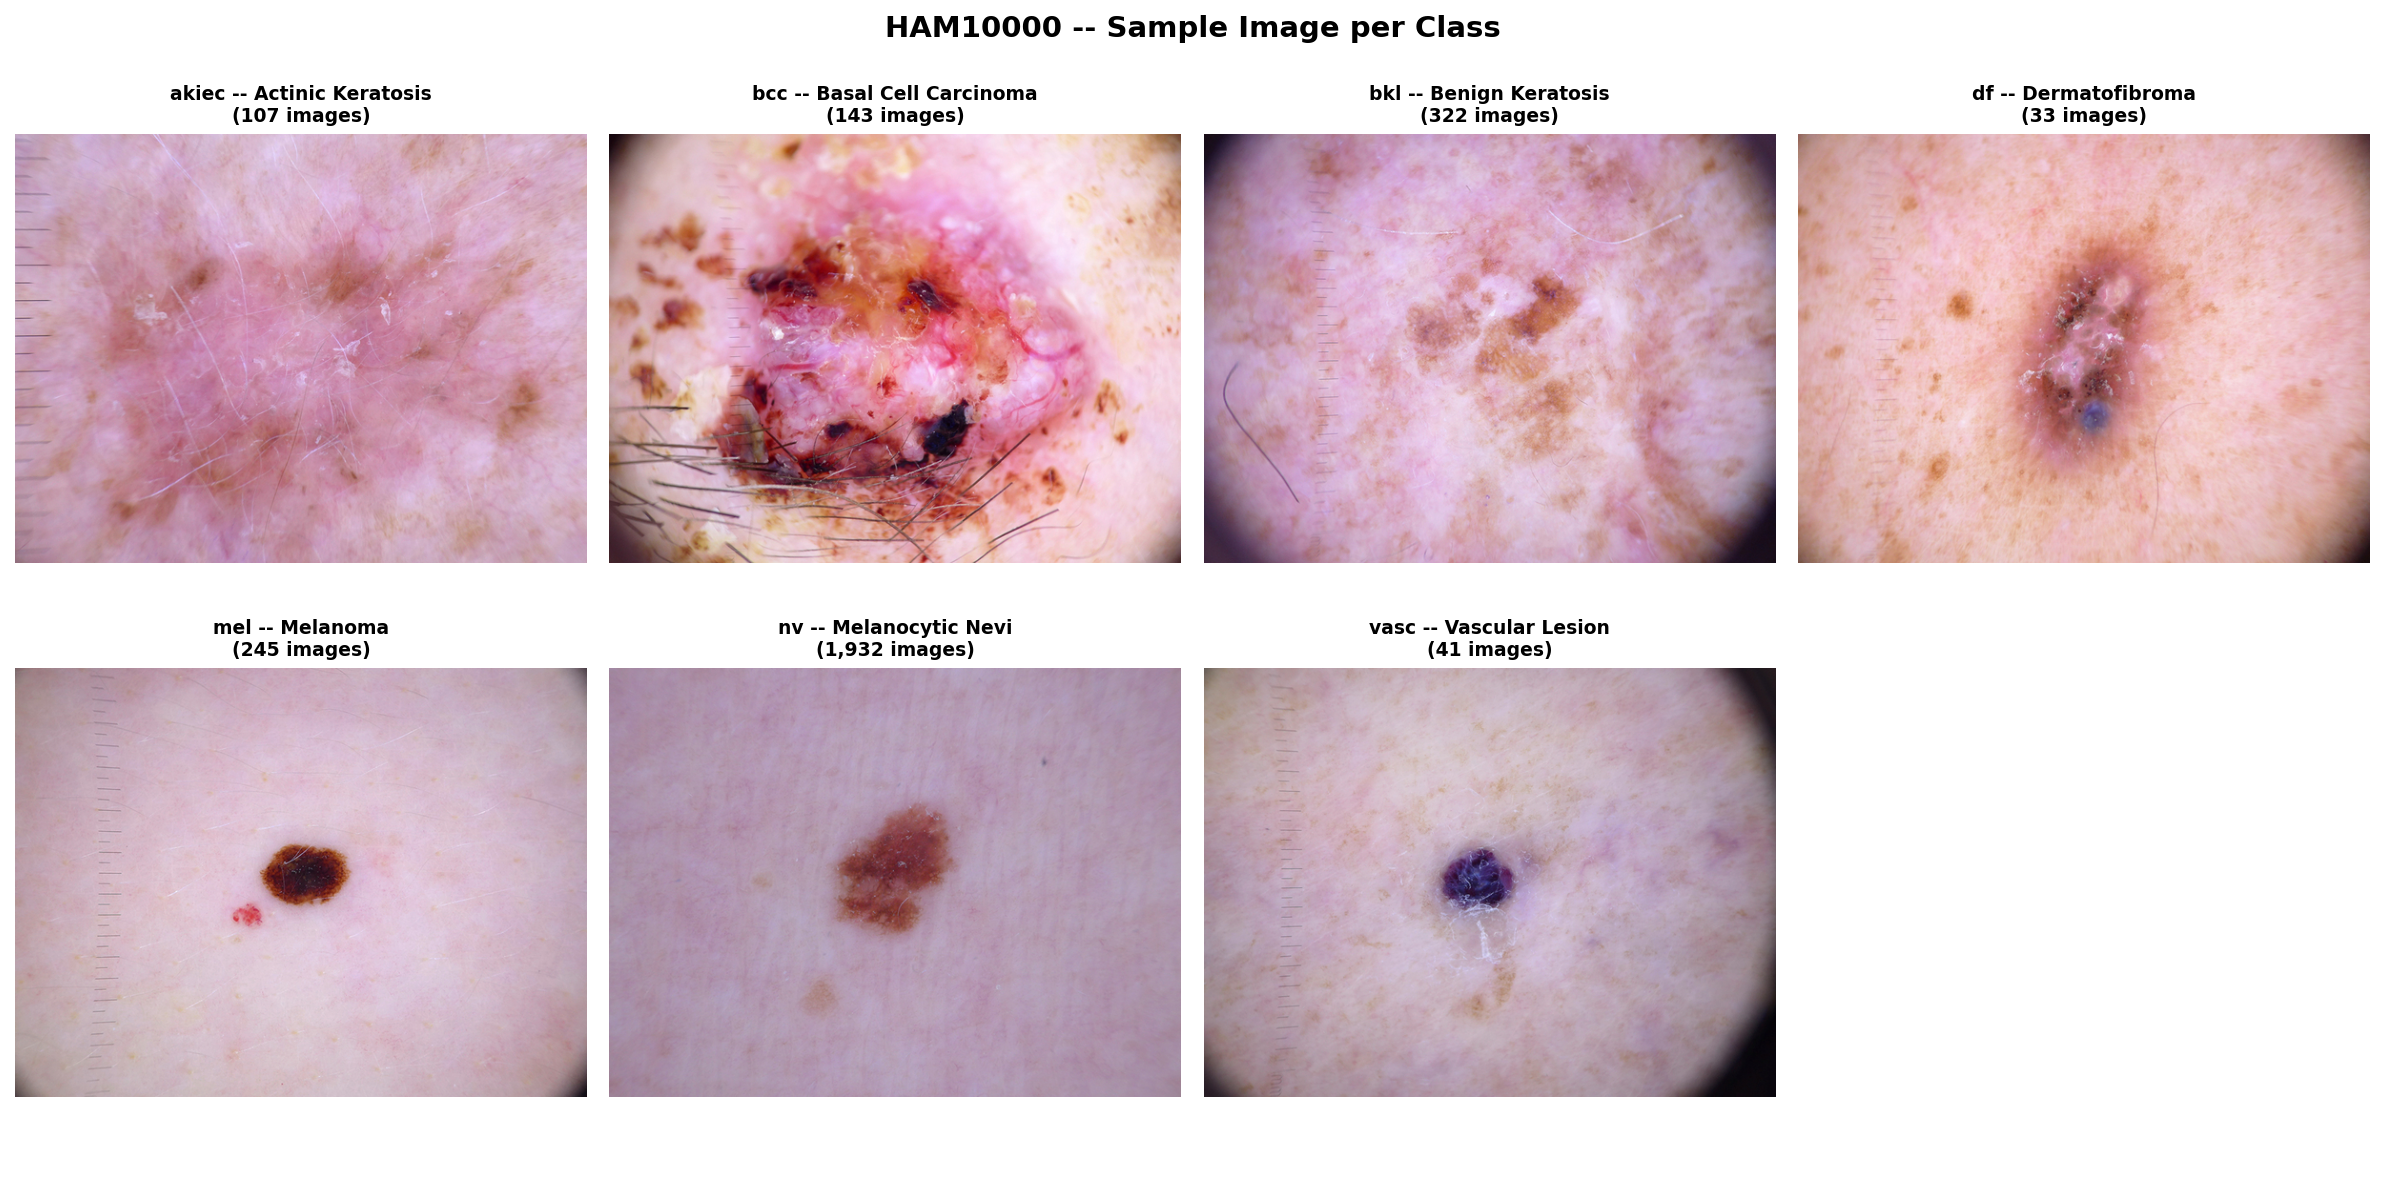

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("HAM10000 -- Sample Image per Class", fontsize=14, fontweight="bold")
for i, cls in enumerate(CLASS_NAMES):
    ax = axes[i//4][i%4]
    sample = df[df["dx"]==cls].iloc[0]
    img = Image.open(sample["path"]).convert("RGB")
    count = len(df[df["dx"]==cls])
    ax.imshow(img)
    ax.set_title(f"{cls} -- {CLASS_FULLNAME[cls]}\n({count:,} images)", fontsize=9, fontweight="bold")
    ax.axis("off")
axes[1][3].axis("off")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_sample_images.png", bbox_inches="tight")
plt.show()

---
## Save EDA Metadata

In [5]:
# Compute per-class synthetic needs -- used by notebook 03
counts_dict = df["dx"].value_counts().to_dict()
syn_needed  = {cls: max(0, TARGET_COUNT - counts_dict.get(cls, 0)) for cls in CLASS_NAMES}

meta = {
    "class_counts":      {cls: int(counts_dict.get(cls,0)) for cls in CLASS_NAMES},
    "synthetic_needed":  {cls: int(v) for cls, v in syn_needed.items()},
    "target_count":      int(TARGET_COUNT),
    "majority_class":    counts.idxmax(),
    "minority_class":    counts.idxmin(),
    "minority_idx":      int(CLASS_TO_IDX[counts.idxmin()]),
}

with open("outputs/eda_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("eda_meta.json saved")
print("\nPer-class synthetic images needed:")
for cls, n in syn_needed.items():
    bar = "#" * min(40, n // 100)
    print(f"  {cls:6s}: {n:5,}  {bar}")
print(f"\nNext -> run 02_baseline_cnn.ipynb")

eda_meta.json saved

Per-class synthetic images needed:
  akiec : 6,598  ########################################
  bcc   : 6,562  ########################################
  bkl   : 6,383  ########################################
  df    : 6,672  ########################################
  mel   : 6,460  ########################################
  nv    : 4,773  ########################################
  vasc  : 6,664  ########################################

Next -> run 02_baseline_cnn.ipynb
